In [1]:
import pandas as pd
import numpy as np

In [4]:
#模拟加载数据（真实场景用pd.read_csv）
data = {
    'Pclass':[3,1,3,1,3],         #舱位等级（1 = 头等，3 = 三等）
    'Sex':['male','female','female','female','male'],
    'Age':[22,38,26,35,np.nan],
    'SibSp':[1,1,0,1,0],           #兄弟姐妹/配偶人数
    'Fare':[7.25,71.28,7.92,53.10,8.05],   #票价
    'Survived':[0,1,1,1,0]        #结果：生还（1），遇难（0）
}
df = pd.DataFrame(data)
print(df.head())

   Pclass     Sex   Age  SibSp   Fare  Survived
0       3    male  22.0      1   7.25         0
1       1  female  38.0      1  71.28         1
2       3  female  26.0      0   7.92         1
3       1  female  35.0      1  53.10         1
4       3    male   NaN      0   8.05         0


In [5]:
#我们用年龄的中位数来填补那个 nan。
df['Age'] = df['Age'].fillna(df['Age'].median())

#既然性别只有男女，我们直接把 female 变成 1，male 变成 0。
df['Sex'] = df['Sex'].map({'female':1,'male':0})

### 随机森林

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# 准备特征 X 和标签 y
X = df.drop('Survived',axis=1)
y = df['Survived']

#切分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#实例化并训练
model = RandomForestClassifier(n_estimators=100, max_depth = 5)
model.fit(X_train, y_train)

# 查看效果
print(f"训练集准确率: {model.score(X_train, y_train):.2f}")

训练集准确率: 1.00


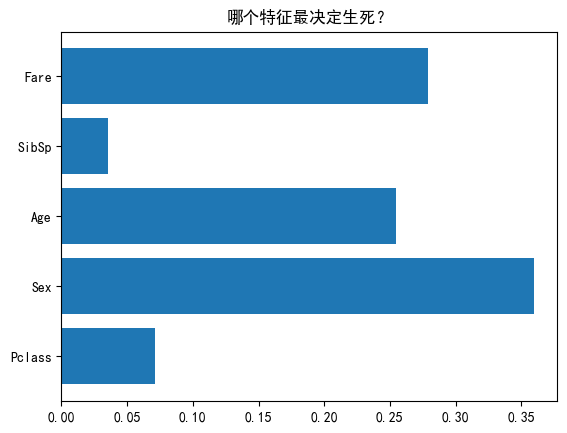

In [8]:
import matplotlib.pyplot as plt

# 获取每个特征的分数
importances = model.feature_importances_
features = X.columns

# 绘图
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.barh(features, importances)
plt.title("哪个特征最决定生死？")
plt.show()